### Importación de datos



In [4]:
import pandas as pd

data_t1 = pd.read_csv("https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv")
data_t2 = pd.read_csv("https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv")
data_t3 = pd.read_csv("https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv")
data_t4 = pd.read_csv("https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv")

data_t1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [5]:
data_t1['Tienda'] = 'Tienda 1'
data_t2['Tienda'] = 'Tienda 2'
data_t3['Tienda'] = 'Tienda 3'
data_t4['Tienda'] = 'Tienda 4'

In [13]:
print("Ingreso total por tienda:")
print(f"* Tienda #1: ${data_t1['Precio'].sum():,.0f}")
print(f"* Tienda #2: ${data_t2['Precio'].sum():,.0f}")
print(f"* Tienda #3: ${data_t3['Precio'].sum():,.0f}")
print(f"* Tienda #4: ${data_t4['Precio'].sum():,.0f}")

Ingreso total por tienda:
* Tienda #1: $1,150,880,400
* Tienda #2: $1,116,343,500
* Tienda #3: $1,098,019,600
* Tienda #4: $1,038,375,700


# 2. Ventas por categoría

In [14]:
tiendas = {
    "Tienda 1": data_t1,
    "Tienda 2": data_t2,
    "Tienda 3": data_t3,
    "Tienda 4": data_t4,
}

for nombre, df in tiendas.items():
    print(f"\n{nombre}:")
    conteo = df["Categoría del Producto"].value_counts()
    print(conteo.to_string())


Tienda 1:
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171

Tienda 2:
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181

Tienda 3:
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177

Tienda 4:
Categoría del Producto
Muebles                    480
Electrónicos               451
Juguetes                   338
Deportes y diversión       

# 3. Calificación promedio de la tienda


In [17]:
tiendas = {
    "Tienda #1": data_t1,
    "Tienda #2": data_t2,
    "Tienda #3": data_t3,
    "Tienda #4": data_t4,
}

print("Calificación promedio por tienda:")
for nombre, df in tiendas.items():
    promedio = df["Calificación"].mean()
    print(f"  {nombre}: {promedio:.2f}")

Calificación promedio por tienda:
  Tienda #1: 3.98
  Tienda #2: 4.04
  Tienda #3: 4.05
  Tienda #4: 4.00


# 4. Productos más y menos vendidos

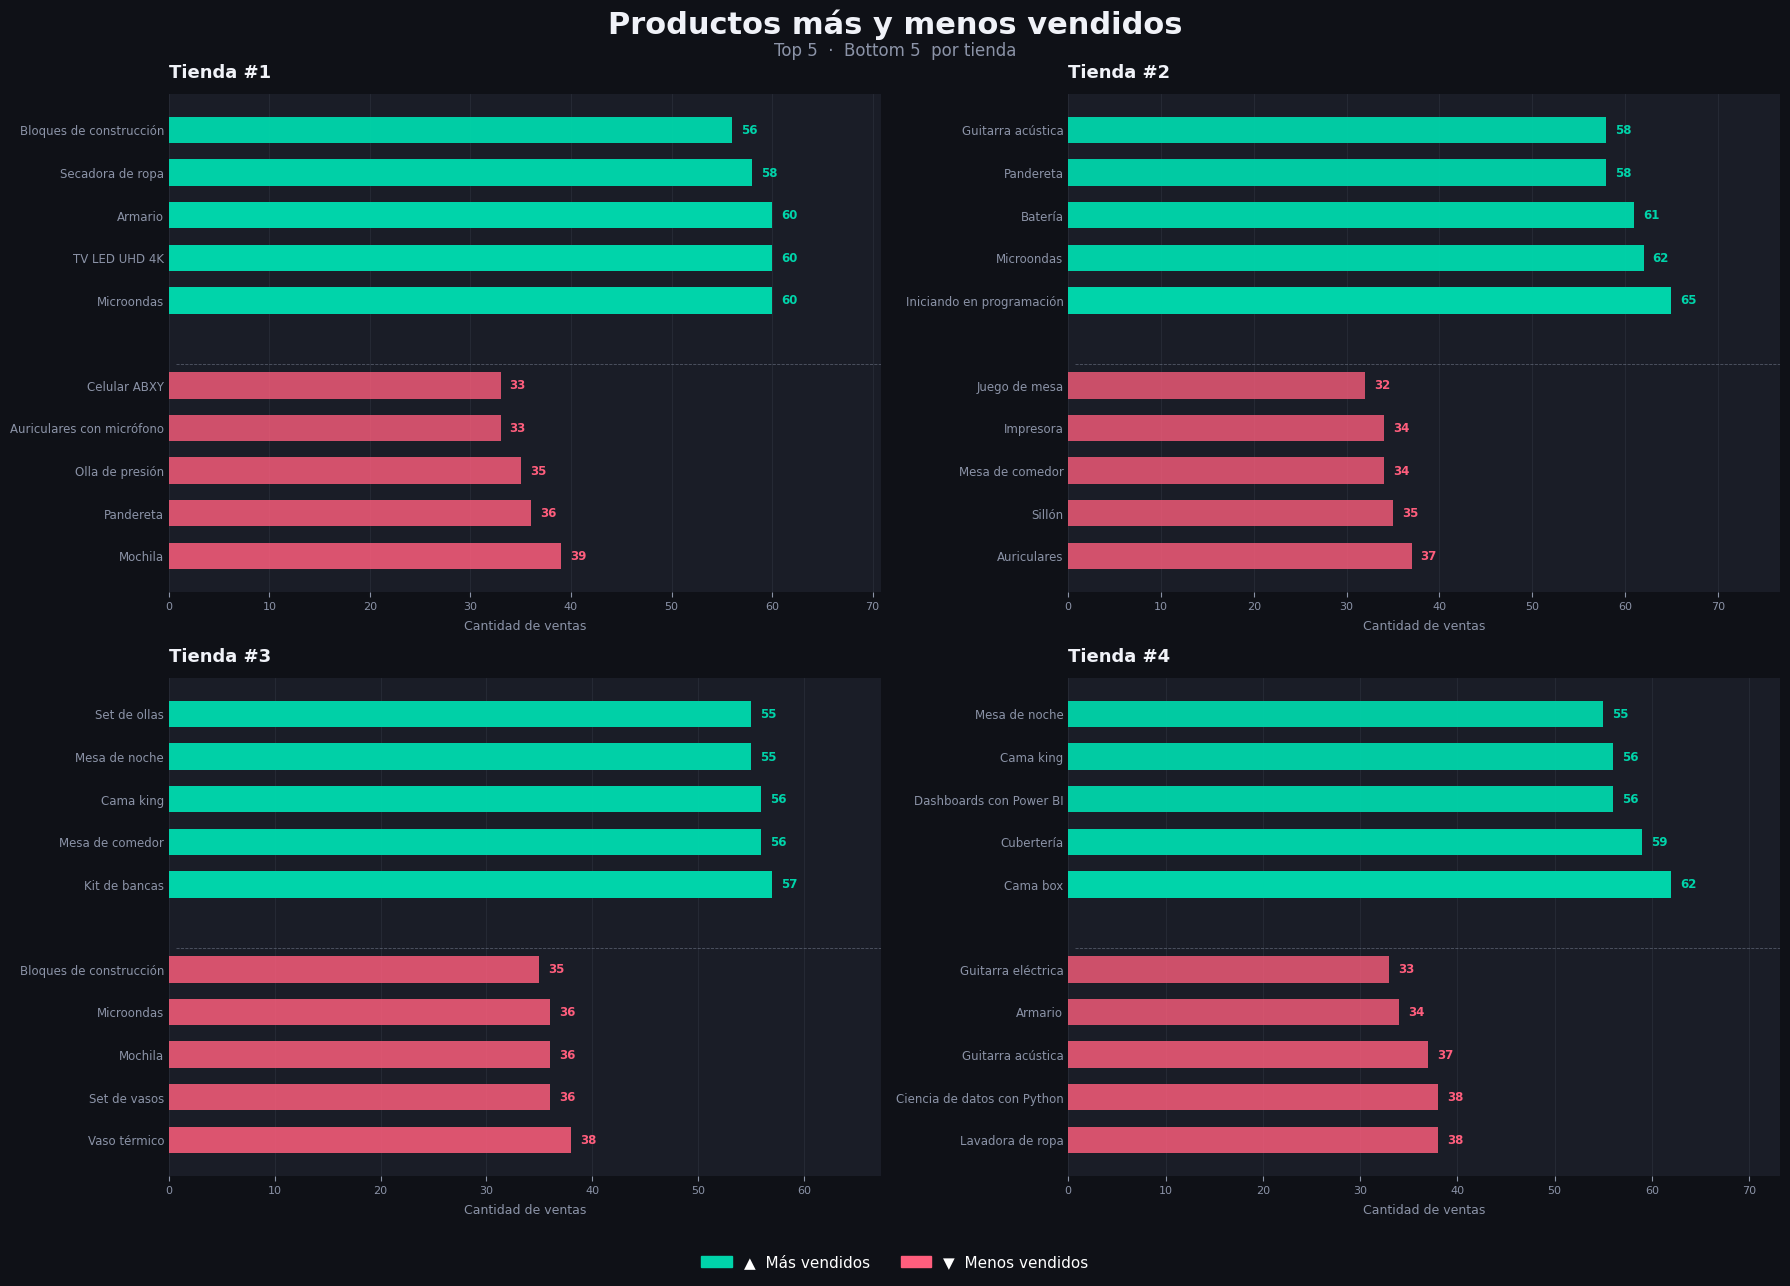

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np

tiendas = {
    "Tienda #1": data_t1,
    "Tienda #2": data_t2,
    "Tienda #3": data_t3,
    "Tienda #4": data_t4,
}

# ── Paleta ───────────────────────────────────────────────
BG_DARK   = "#0f1117"
BG_PANEL  = "#1a1d27"
COLOR_TOP = "#00d4aa"   # verde-teal
COLOR_BOT = "#ff5e7d"   # rosa-rojo
TICK_CLR  = "#8b93a7"
TITLE_CLR = "#f0f2f8"

# ── Figura ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.patch.set_facecolor(BG_DARK)

# Título principal
fig.text(
    0.5, 0.98,
    "Productos más y menos vendidos",
    ha="center", va="top",
    fontsize=22, fontweight="bold", color=TITLE_CLR,
    fontfamily="DejaVu Sans",
)
fig.text(
    0.5, 0.955,
    "Top 5  ·  Bottom 5  por tienda",
    ha="center", va="top",
    fontsize=12, color=TICK_CLR,
)

for ax, (nombre, df) in zip(axes.flatten(), tiendas.items()):
    ax.set_facecolor(BG_PANEL)
    for spine in ax.spines.values():
        spine.set_visible(False)

    vc   = df["Producto"].value_counts()
    top5 = vc.head(5)
    bot5 = vc.tail(5)

    productos = list(bot5.index) + [""] + list(top5.index)
    ventas    = list(bot5.values) + [0]  + list(top5.values)
    colores   = [COLOR_BOT] * 5 + ["none"] + [COLOR_TOP] * 5

    y_pos = np.arange(len(productos))

    # Barras con alpha degradado según magnitud
    for i, (val, col) in enumerate(zip(ventas, colores)):
        if col == "none":
            continue
        alpha = 0.55 + 0.45 * (val / max(ventas))
        ax.barh(y_pos[i], val, color=col, alpha=alpha,
                edgecolor="none", height=0.62)

    # Línea separadora entre grupos
    ax.axhline(y=4.5, color=TICK_CLR, linewidth=0.6,
               linestyle="--", alpha=0.5, xmin=0.01)

    # Etiquetas de valor
    for i, val in enumerate(ventas):
        if val == 0:
            continue
        ax.text(
            val + max(ventas) * 0.015,
            y_pos[i],
            str(val),
            va="center", ha="left",
            fontsize=8.5, fontweight="bold",
            color=colores[i],
        )

    # Etiquetas del eje Y
    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        productos,
        fontsize=8.5, color=TICK_CLR,
    )

    # Grid vertical sutil
    ax.xaxis.grid(True, color=TICK_CLR, alpha=0.12, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", colors=TICK_CLR, labelsize=8)
    ax.tick_params(axis="y", length=0)
    ax.set_xlim(0, max(ventas) * 1.18)

    # Título del panel
    ax.set_title(
        nombre,
        fontsize=13, fontweight="bold",
        color=TITLE_CLR, pad=12, loc="left",
    )
    ax.set_xlabel("Cantidad de ventas", fontsize=9, color=TICK_CLR, labelpad=6)

# ── Leyenda ───────────────────────────────────────────────
patch_top = mpatches.Patch(color=COLOR_TOP, label="▲  Más vendidos")
patch_bot = mpatches.Patch(color=COLOR_BOT, label="▼  Menos vendidos")
fig.legend(
    handles=[patch_top, patch_bot],
    loc="lower center", ncol=2,
    fontsize=11, frameon=False,
    labelcolor="white",
    bbox_to_anchor=(0.5, 0.0),
)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig(
    "productos_mas_menos_vendidos.png",
    dpi=150, bbox_inches="tight",
    facecolor=BG_DARK,
)
plt.show()

# 5. Envío promedio por tienda

In [23]:
tiendas = {
    "Tienda 1": data_t1,
    "Tienda 2": data_t2,
    "Tienda 3": data_t3,
    "Tienda 4": data_t4,
}

print("Costo de envío promedio por tienda (pagado por el cliente):")
for nombre, df in tiendas.items():
    promedio = df["Costo de envío"].mean()
    print(f"  {nombre}: {promedio:.2f}")

Costo de envío promedio por tienda (pagado por el cliente):
  Tienda 1: 26018.61
  Tienda 2: 25216.24
  Tienda 3: 24805.68
  Tienda 4: 23459.46


C:\Users\Andres\AppData\Local\Temp\ipykernel_24292\1479548916.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(nombres, color=TICK_CLR, fontsize=8.5)
C:\Users\Andres\AppData\Local\Temp\ipykernel_24292\1479548916.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(nombres, color=TICK_CLR, fontsize=8.5)


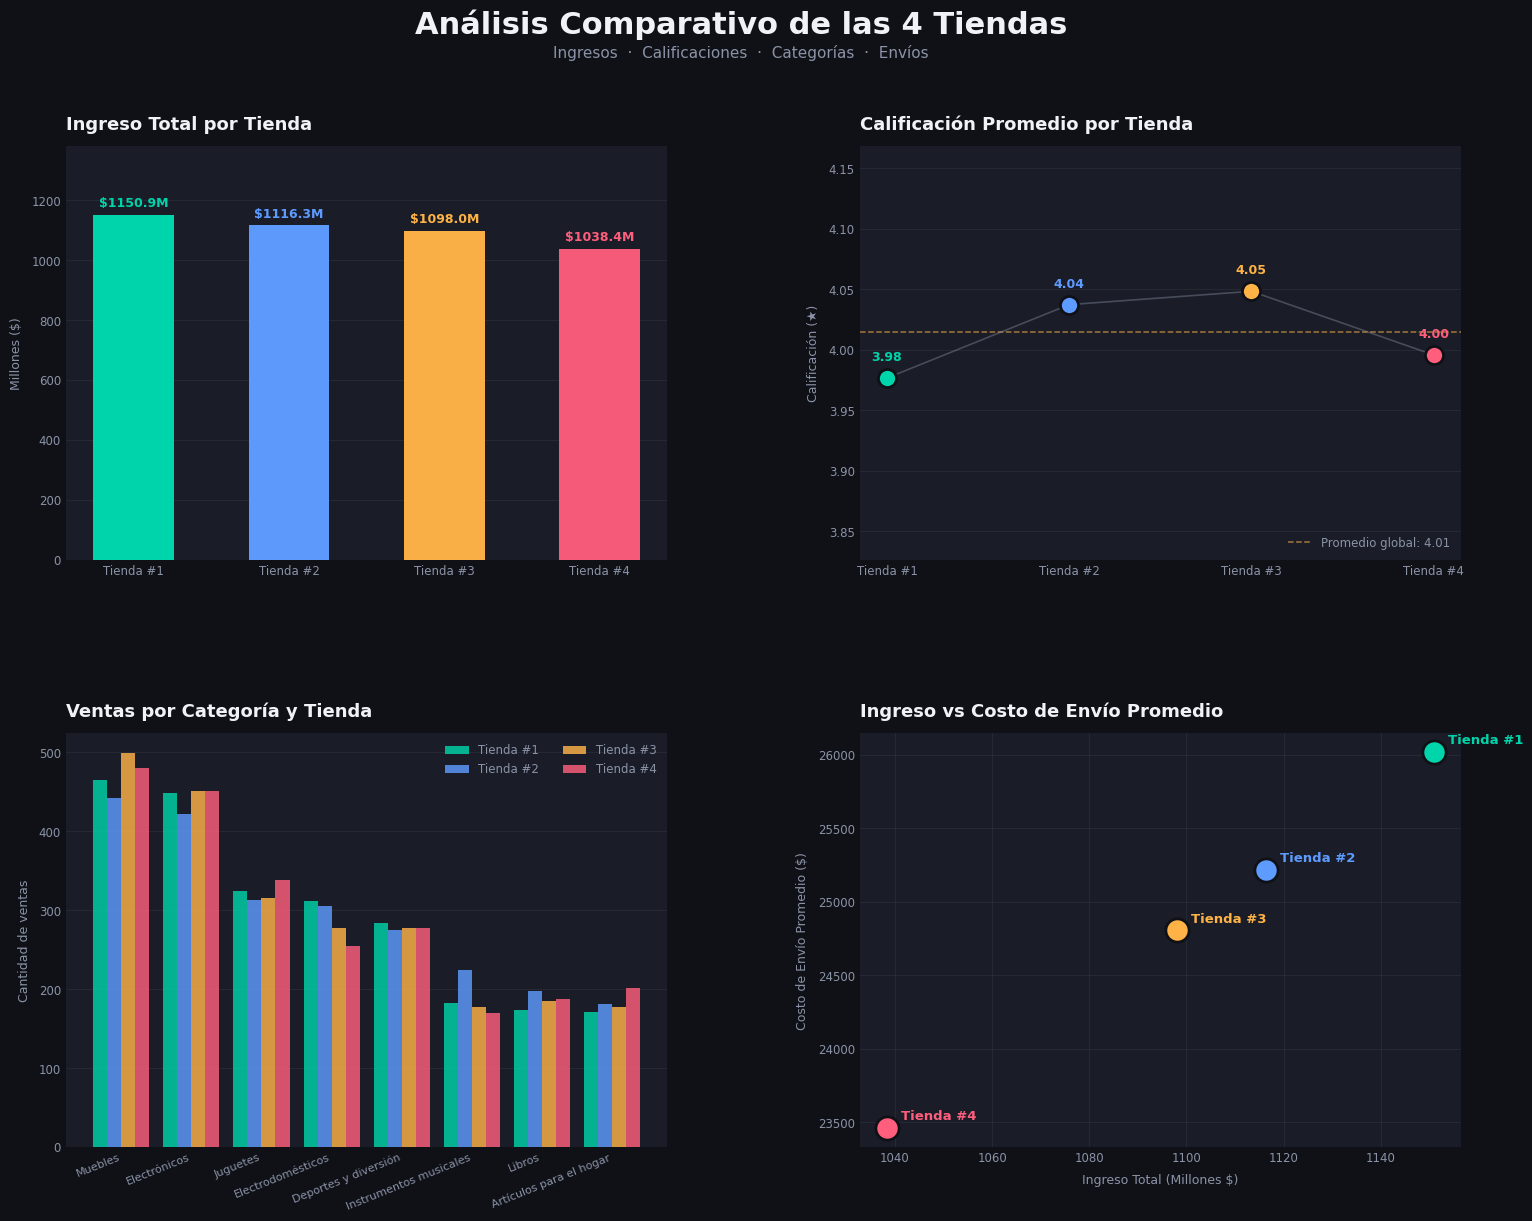

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

dfs = {
    "Tienda #1": data_t1,
    "Tienda #2": data_t2,
    "Tienda #3": data_t3,
    "Tienda #4": data_t4,
}

nombres        = list(dfs.keys())
ingresos       = [df["Precio"].sum() / 1e6 for df in dfs.values()]
calificaciones = [df["Calificación"].mean() for df in dfs.values()]
envios         = [df["Costo de envío"].mean() for df in dfs.values()]

# ── Paleta & estilos ──────────────────────────────────────
BG_DARK    = "#0f1117"
BG_PANEL   = "#1a1d27"
TICK_CLR   = "#8b93a7"
TITLE_CLR  = "#f0f2f8"
PALETTE    = ["#00d4aa", "#5e9bff", "#ffb347", "#ff5e7d"]
ACCENT     = "#ffffff"

fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor(BG_DARK)

# Título principal + subtítulo
fig.text(0.5, 0.985, "Análisis Comparativo de las 4 Tiendas",
         ha="center", va="top", fontsize=22, fontweight="bold",
         color=TITLE_CLR)
fig.text(0.5, 0.958, "Ingresos  ·  Calificaciones  ·  Categorías  ·  Envíos",
         ha="center", va="top", fontsize=11, color=TICK_CLR)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

def style_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_facecolor(BG_PANEL)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=TICK_CLR, labelsize=8.5, length=0)
    ax.xaxis.label.set_color(TICK_CLR)
    ax.yaxis.label.set_color(TICK_CLR)
    ax.set_title(title, fontsize=13, fontweight="bold",
                 color=TITLE_CLR, pad=12, loc="left")
    if xlabel: ax.set_xlabel(xlabel, fontsize=9, color=TICK_CLR, labelpad=6)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9, color=TICK_CLR, labelpad=6)
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, color=TICK_CLR, alpha=0.12, linewidth=0.6)
    ax.set_axisbelow(True)

# ── 1: Ingresos totales ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, "Ingreso Total por Tienda", ylabel="Millones ($)")

for i, (nombre, val, col) in enumerate(zip(nombres, ingresos, PALETTE)):
    alpha = 0.6 + 0.4 * (val / max(ingresos))
    ax1.bar(nombre, val, color=col, alpha=alpha,
            edgecolor="none", width=0.52)
    ax1.text(i, val + max(ingresos) * 0.015,
             f"${val:.1f}M", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color=col)

ax1.set_ylim(0, max(ingresos) * 1.2)
ax1.set_xticklabels(nombres, color=TICK_CLR, fontsize=8.5)

# ── 2: Calificación promedio ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, "Calificación Promedio por Tienda", ylabel="Calificación (★)")
ax2.yaxis.grid(True, color=TICK_CLR, alpha=0.12, linewidth=0.6)

prom_global = sum(calificaciones) / len(calificaciones)
ax2.axhline(prom_global, color="#ffb347", linestyle="--",
            linewidth=1.1, alpha=0.6, label=f"Promedio global: {prom_global:.2f}")

for col, x, y in zip(PALETTE, nombres, calificaciones):
    ax2.plot(x, y, "o", markersize=13, color=col,
             markeredgecolor=BG_DARK, markeredgewidth=2, zorder=5)
    ax2.text(x, y + 0.012, f"{y:.2f}",
             ha="center", va="bottom", fontsize=9,
             fontweight="bold", color=col)

ax2.plot(nombres, calificaciones, color=TICK_CLR,
         linewidth=1.2, alpha=0.4, zorder=3)
ax2.set_ylim(min(calificaciones) - 0.15, max(calificaciones) + 0.12)
ax2.set_xticklabels(nombres, color=TICK_CLR, fontsize=8.5)
ax2.legend(fontsize=8.5, frameon=False, labelcolor=TICK_CLR,
           loc="lower right")

# ── 3: Ventas por categoría ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3, "Ventas por Categoría y Tienda", ylabel="Cantidad de ventas")
ax3.yaxis.grid(True, color=TICK_CLR, alpha=0.12, linewidth=0.6)

tienda_ref = list(dfs.values())[0]
categorias = list(tienda_ref["Categoría del Producto"].value_counts().index)
x = np.arange(len(categorias))
width = 0.2

for i, (nombre, df, col) in enumerate(zip(nombres, dfs.values(), PALETTE)):
    vc   = df["Categoría del Producto"].value_counts()
    vals = [vc.get(c, 0) for c in categorias]
    ax3.bar(x + i * width, vals, width, label=nombre,
            color=col, alpha=0.82, edgecolor="none")

ax3.set_xticks(x + width * 1.5)
ax3.set_xticklabels(categorias, rotation=22, ha="right",
                    fontsize=8, color=TICK_CLR)
ax3.legend(fontsize=8.5, frameon=False, labelcolor=TICK_CLR,
           ncol=2, loc="upper right")

# ── 4: Ingreso vs Costo de envío ──────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4, "Ingreso vs Costo de Envío Promedio",
         xlabel="Ingreso Total (Millones $)",
         ylabel="Costo de Envío Promedio ($)")
ax4.yaxis.grid(True, color=TICK_CLR, alpha=0.12, linewidth=0.6)
ax4.xaxis.grid(True, color=TICK_CLR, alpha=0.12, linewidth=0.6)

for nombre, col, ing, env in zip(nombres, PALETTE, ingresos, envios):
    ax4.scatter(ing, env, s=280, color=col, zorder=5,
                edgecolors=BG_DARK, linewidth=2)
    ax4.annotate(nombre, (ing, env),
                 textcoords="offset points", xytext=(10, 6),
                 fontsize=9.5, fontweight="bold", color=col)

plt.savefig("analisis_visualizaciones.png", dpi=150,
            bbox_inches="tight", facecolor=BG_DARK)
plt.show()

# 📊 Informe Final — Análisis de las 4 Tiendas del Sr. Juan

---

## 1. Introducción

El presente informe analiza el desempeño de las cuatro tiendas del Sr. Juan, con el fin de identificar cuál presenta el rendimiento más bajo y debería considerarse para la venta. Se evaluaron cinco dimensiones clave: **ingresos totales**, **ventas por categoría**, **calificaciones promedio**, **productos más y menos vendidos** y **costo de envío promedio**.

---

## 2. Desarrollo del Análisis

### 2.1 Ingresos Totales

| Tienda   | Ingreso Total      | Posición | Diferencia vs #1   |
|----------|--------------------|----------|--------------------|
| Tienda 1 | $1.150.880.400     | 🥇 1°    | —                  |
| Tienda 2 | $1.116.343.500     | 2°       | -$34.536.900       |
| Tienda 3 | $1.098.019.600     | 3°       | -$52.860.800       |
| Tienda 4 | $1.038.375.700     | 🔴 4°    | **-$112.504.700**  |

**Tienda 1** lidera con $1.150 millones, mientras que **Tienda 4** es la de menor ingreso, con una brecha de ~$112 M respecto a la líder — casi un **10% menos**.

---

### 2.2 Ventas por Categoría de Producto

En todas las tiendas, **Muebles** y **Electrónicos** son las categorías más vendidas de forma consistente.

| Tienda   | Categoría más vendida | Unidades | Categoría menos vendida     | Unidades |
|----------|-----------------------|----------|-----------------------------|----------|
| Tienda 1 | Muebles               | 465      | Artículos para el hogar     | 171      |
| Tienda 2 | Muebles               | 442      | Artículos para el hogar     | 181      |
| Tienda 3 | Muebles               | 499      | Artículos para el hogar     | 177      |
| Tienda 4 | Muebles               | 480      | **Instrumentos musicales**  | **170**  |

> ⚠️ **Tienda 4** es la única con *Instrumentos musicales* como categoría menos vendida, indicando un segmento con demanda particularmente débil en su catálogo.

---

### 2.3 Calificación Promedio de Clientes

Promedio global: **4.02**

| Tienda   | Calificación Promedio | Posición | Nota                      |
|----------|-----------------------|----------|---------------------------|
| Tienda 3 | 4.05                  | 🥇 1°    | Mejor satisfacción        |
| Tienda 2 | 4.04                  | 2°       | Por encima del promedio   |
| Tienda 4 | 4.00                  | 3°       | Levemente bajo el promedio|
| Tienda 1 | 3.98                  | 🔴 4°    | Por debajo del promedio   |

**Tienda 1** tiene la calificación más baja (3.98). **Tienda 4** se ubica tercera con 4.00, también por debajo del promedio global.

---

### 2.4 Productos más y menos Vendidos

| Tienda   | Producto más vendido          | Ventas | Producto menos vendido    | Ventas |
|----------|-------------------------------|--------|---------------------------|--------|
| Tienda 1 | Microondas                    | 60     | Celular ABXY              | 33     |
| Tienda 2 | Iniciando en programación     | **65** | Juego de mesa             | 32     |
| Tienda 3 | Kit de bancas                 | 57     | Bloques de construcción   | 35     |
| Tienda 4 | Cama box                      | 62     | Guitarra eléctrica        | 33     |

**Tienda 2** lidera con 65 ventas en su producto estrella. Los productos menos vendidos son similares entre tiendas (32–35 unidades).

---

### 2.5 Costo de Envío Promedio

| Tienda   | Costo Promedio de Envío | Posición        | Diferencia vs mejor |
|----------|-------------------------|-----------------|---------------------|
| Tienda 4 | $23.459                 | 🥇 Más bajo     | —                   |
| Tienda 3 | $24.806                 | 2°              | +$1.347             |
| Tienda 2 | $25.216                 | 3°              | +$1.757             |
| Tienda 1 | $26.019                 | 🔴 Más alto     | +$2.560             |

**Tienda 4** ofrece el menor costo de envío ($23.459), aunque este beneficio **no se traduce** en mayores ingresos ni mejor calificación.

---

## 3. Resumen Comparativo

| Indicador               | Tienda 1  | Tienda 2 | Tienda 3  | Tienda 4      |
|-------------------------|-----------|----------|-----------|---------------|
| Ingreso total           | 🥇 1°     | 2°       | 3°        | 🔴 4°         |
| Calificación promedio   | 🔴 4°     | 2°       | 🥇 1°     | 3°            |
| Costo de envío          | 🔴 Alto   | Medio    | Medio     | 🥇 Bajo       |
| Categoría top           | Muebles   | Muebles  | Muebles   | Muebles       |
| Producto más vendido    | 60 uds.   | 65 uds.  | 57 uds.   | 62 uds.       |

---

## 4. Conclusión y Recomendación

Luego de evaluar los cinco indicadores analizados, la recomendación es:

> ### 🔴 El Sr. Juan debería vender la **Tienda 4**

Las razones que respaldan esta decisión:

1. **Menores ingresos totales del grupo.** Con $1.038 millones, es la única tienda que no supera los $1.100 millones y acumula una diferencia de $112 M respecto a la líder.
2. **Mix de categorías con debilidad exclusiva.** Es la única tienda donde *Instrumentos musicales* es la categoría menos vendida, un segmento que no representa un problema en las demás tiendas.
3. **Calificación promedio moderada (4.00).** Superada por Tienda 2 (4.04) y Tienda 3 (4.05), refleja una satisfacción de cliente por debajo del grupo.
4. **Su único punto positivo no genera impacto real.** El menor costo de envío ($23.459) no se traduce en ventaja competitiva medible en ingresos ni en satisfacción.

En contraposición, **Tienda 1** — a pesar de tener la calificación más baja — es la más rentable y el activo más valioso del portafolio, por lo que sería la menos indicada para vender.

